

## **Image Classification and Convolutional Neural Networks (CNNs)** [10pts]

In this class we will be relying on Python as a programming language and pytorch as a primary framework of choice. For an introduction to Python for image manipulation you can do a refresher by first completing this notebook: [[Python, Numpy and Image Processing](https://colab.research.google.com/drive/1fI8_ga1ZG1vGPpJUwBMdxnPX6ntrUgrh)]. For a gentle introduction to Pytorch you can complete first this notebook: [[Python, Pytorch and Plotting](https://colab.research.google.com/drive/1UQM4Lzs1sKbmZ7g3D1f98ATTSZM5EyGW?usp=sharing)].

### **0. Preliminaries**
In this section, we will review some basic Pytorch to demonstrate its capabilities for gradient-based optimization. Consider for instance the following function:

$$ y = 4x + 3z^2$$

Your task is to find the gradient $\nabla y = \left(\frac{\partial y}{\partial x}, \frac{\partial y}{\partial z}\right)$ for when $x = 2$ and $z = 3$. How do we do this? There are three ways we can do this.

#### **0.1 Analytical derivation**
First, we can compute the analytical formula for this function as follows:

$$\frac{\partial y}{\partial x} = 4 \quad\text{ and }\quad \frac{\partial y}{\partial z} = 6z$$

We can easily see that the gradient at $(x,z) = (2, 3)$ is $\nabla y = (4, 18) $. No need to write any code.

#### **0.2 Numerical approximation**
The other method we can apply is based on a numerical approximation using the definition of derivatives. Let's have $y = f(x,z)$, then the definitions of partial derivatives can be expressed as follows:

$$ \frac{\partial}{\partial x} f(x,z) = \lim_{h_x \to 0} \frac{f(x + h_x, z) - f(x, z)}{h_x}$$

$$ \frac{\partial}{\partial z} f(x,z) = \lim_{h_z \to 0} \frac{f(x, z + h_z) - f(x, z)}{h_z}$$

We can quickly compute this below using some basic Python functions.

In [1]:
def f(x,z):
  return 4 * x + 3 * z * z

def grad_x(f, x, z, h = 0.0001):
  return (f(x + h, z) - f(x, z)) / h

def grad_z(f, x, z, h = 0.0001):
  return (f(x, z + h) - f(x, z)) / h

print(grad_x(f, 2, 3), grad_z(f, 2, 3))

3.9999999999906777 18.000300000053926


As we can see, the approximation is fairly correct, returning almost the same result as the analytical derivation.

#### **0.3 Pytorch autograd**

Writing your own derivations is fine but pytorch already implements the gradient based computation for all basic operations you might need and it keeps track of the operations that are being applied when using the Pytorch tensor datatype. Anytime you need to compute gradients you can call the backward() function on a tensor and it will apply the chain rule of calculus to compute the derivatives for all the history of operations applied to said tensor.

In [2]:
import torch

# This function assumes, x, z are pytorch tensors but it looks the
# same as the earlier function. We could also restrict the data types in python3.
def f(x: torch.tensor, z: torch.tensor):
  return 4 * x + 3 * z * z

x = torch.tensor(2.0, requires_grad = True)
z = torch.tensor(3.0, requires_grad = True)

# Compute the value of y.
y = f(x,z)

# Compute the gradients for all variables.
y.backward()

# Print the gradients
print(x.grad, z.grad)

tensor(4.) tensor(18.)


We can see that we can obtain the same result, except the Pytorch function is much more general. For starters, $x$ and $z$ could be vectors in this implementation without changing anything. There is no need to compute the analytical derivation and there is no need to have a separate function for each partial derivative. Another thing to keep in mind, usually we will be optimizing variables that we name $W = [w_1, w_2, ...]$ and we will use $y$ and $x$ to denote constants since those we use to represent the training data, so let us not get confused by this. You will be able to see this more clearly in the first part of the assignment section.

### **1. The SUN Dataset** **[2pts]**

In 2009, a group of researchers introduced **SUN397**, a large-scale image dataset designed to cover a wide variety of visual **scene categories** (e.g., kitchens, classrooms, forests, streets). More information about the dataset can be found here:  
https://3dvision.princeton.edu/projects/2010/SUN/

The dataset contains **397 scene categories**, with **at least 100 images per category**, and is commonly used to benchmark scene recognition models. The full dataset is distributed as a compressed archive of approximately **39 GB**, which makes it impractical to use directly for this assignment so we will use a subset of this dataset.


#### **1.1 Downloading the Data**


For this assignment, we provide a **curated subset** of the SUN dataset with the following properties:

- **20 scene categories**
- **50 images per category** (1,000 images total)
- Images are preprocessed so that their **longest side is 256 pixels** (aspect ratio preserved)

This subset preserves the diversity and challenges of scene recognition while keeping computational requirements manageable. All students will work with the same curated data to ensure fair comparison across models.

In [3]:

# This command downloads the files with the prepackaged contents.
import os
import urllib.request
import tarfile

urls = [
    "http://www.cs.rice.edu/~vo9/deep-vislang/SUN20-train-sm.tar.gz",
    "http://www.cs.rice.edu/~vo9/deep-vislang/SUN20-val.tar.gz"
]

for url in urls:
    filename = url.split('/')[-1]
    if not os.path.exists(filename):
        print(f"Downloading {filename}...")
        urllib.request.urlretrieve(url, filename)
    else:
        print(f"{filename} already exists.")

# Extract the archives
for filename in ["SUN20-train-sm.tar.gz", "SUN20-val.tar.gz"]:
    if os.path.exists(filename):
        print(f"Extracting {filename}...")
        with tarfile.open(filename, 'r:gz') as tar:
            tar.extractall()
    else:
        print(f"Error: {filename} not found.")

print("Done!")

SUN20-train-sm.tar.gz already exists.
SUN20-val.tar.gz already exists.
Extracting SUN20-train-sm.tar.gz...


/var/folders/v3/bk349gcs0fv4vrdxzx45yjh80000gn/T/ipykernel_18129/1446430780.py:24: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall()


Extracting SUN20-val.tar.gz...
Done!


#### **1.2 Creating a Custom Data Loader**


In PyTorch, datasets are defined by creating a class that inherits from  
`torch.utils.data.Dataset`. Such a class must implement two methods:

- `__len__`: returns the total number of samples in the dataset
- `__getitem__`: returns a single sample given an index (typically an image and its label)

Below we provide a simple implementation of a custom dataset class for the **SUN20** subset. This class is responsible for:
- Reading image files from disk
- Mapping category names to numeric labels
- Returning `(image, label)` pairs compatible with PyTorch dataloaders

Note: The dataset class does not perform batching or shuffling. This is handled by torch.utils.data.DataLoader.

In [4]:
import os
import torch
import torch.utils.data
from PIL import Image, ImageFile

# Custom dataset class for the SUN20 dataset
class SUN20(torch.utils.data.Dataset):

    def __init__(self, split='train', transform=None):
        self.categories = open(f'SUN20/{split}/ClassName.txt').read().split('\n')[:-1]
        self.categories = sorted(self.categories)

        self.category2index = {
            category: idx for idx, category in enumerate(self.categories)
        }

        self.transform = transform
        self.imagepaths = []
        self.labels = []

        for category in self.categories:
            category_dir = f'SUN20/{split}/{category}'
            if not os.path.isdir(category_dir):
                continue   # 🔧 skip missing categories

            imagenames = os.listdir(category_dir)
            self.imagepaths += [
                os.path.join(category_dir, name) for name in imagenames
            ]
            self.labels += [self.category2index[category]] * len(imagenames)

        sorted_pairs = sorted(zip(self.imagepaths, self.labels))
        if sorted_pairs:
            self.imagepaths, self.labels = zip(*sorted_pairs)
        else:
            self.imagepaths, self.labels = [], []

    def __getitem__(self, index):
        ImageFile.LOAD_TRUNCATED_IMAGES = True  # 🔑 must be here (worker-safe)
        while True:
            try:
                image = Image.open(self.imagepaths[index]).convert("RGB")
                if self.transform:
                    image = self.transform(image)
                return image, self.labels[index]
            except Exception:
                index = (index + 1) % len(self.imagepaths)

    def __len__(self):
        return len(self.imagepaths)

#### **1.3 Using the Custom Data Loader**


Below we demonstrate how to use the `SUN20` dataset class and how to explore images from the dataset.

Before training any vision (or vision–language) model, it is essential to **inspect the data**: verify that images load correctly, labels match visual content, and image sizes are reasonable. This step often catches bugs and dataset issues early.

The following code illustrates basic dataset usage and visualization.

This dataset has 1000 training images
Image 0 is a "/a/arch"
Image size is 250 x 379


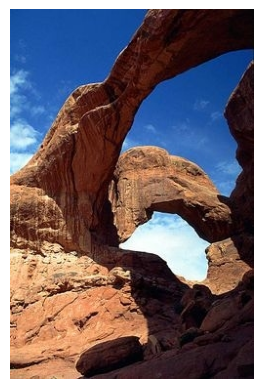

In [5]:
import matplotlib.pyplot as plt

# Instantiate the training dataset
trainset = SUN20(split='train')

image_index = 0  # Try different indices

# 1. __len__ allows us to query dataset size
print(f'This dataset has {len(trainset)} training images')

# 2. __getitem__ returns an (image, label) pair
img, label = trainset[image_index]

print(f'Image {image_index} is a "{trainset.categories[label]}"')
print(f'Image size is {img.width} x {img.height}')

# Visualize the image
plt.figure()
plt.imshow(img)
plt.axis('off')
plt.show()


#### **1.4 Exploring Images in the SUN20 Dataset** **[2pts]**

***Dataset Statistics (Portrait Images):***  
In this section you will demonstrate that you can iterate over our dataset and extract basic image properties.

An image is considered **portrait** if **H > W** (strictly greater).

**Task:**  
Compute, for each of the 20 categories, the number of portrait images in:
- the **training split** (`split='train'`)
- the **validation split** (`split='val'`)

Then print one line per category in the exact format below:

`{train_count} training images in portrait mode (H > W) and {val_count} validation images in portrait mode (H > W) for {category}: Total {train_count + val_count}`

Finally, sort the printed lines in **decreasing order by Total**.  

**Grading (1pt):**  
- Correct counts + correct sorting + exact print format  
- Efficient + readable implementation (should run in < 0.4 seconds on average)

**Performance requirement:**  
Your solution should run in **< 0.4 seconds on average** (measured over 3 runs in Colab).  
You need to enter details of your solution here: [[leaderboard link](https://docs.google.com/spreadsheets/d/15_dl6yAKicVuW3xlr5FuFP_QO8bYPfF5BF-c_iT5lRc/edit?usp=sharing)]

**Optional (ungraded) challenge:**  
Try to minimize runtime and/or code length (lines of code) while keeping the code readable.  

In [6]:
import sys
sys.path.insert(0, '/tmp/pylibs')
# Now import works

import torchvision

In [7]:
import imagesize
from itertools import chain, repeat

tr = SUN20(split="train"); va = SUN20(split="val"); cats = tr.categories; K = len(cats); get = imagesize.get
ct = [0]*K; cv = [0]*K
for p, l, is_val in chain(zip(tr.imagepaths, tr.labels, repeat(0)), zip(va.imagepaths, va.labels, repeat(1))):
    w, h = get(p)
    if h > w: (cv if is_val else ct)[l] += 1
for i in sorted(range(K), key=lambda i: ct[i] + cv[i], reverse=True):
    print(f"{ct[i]} training images in portrait mode (H > W) and {cv[i]} validation images in portrait mode (H > W) for {cats[i]}: Total {ct[i]+cv[i]}")

42 training images in portrait mode (H > W) and 46 validation images in portrait mode (H > W) for /s/shower: Total 88
40 training images in portrait mode (H > W) and 35 validation images in portrait mode (H > W) for /t/tower: Total 75
23 training images in portrait mode (H > W) and 20 validation images in portrait mode (H > W) for /s/skyscraper: Total 43
25 training images in portrait mode (H > W) and 17 validation images in portrait mode (H > W) for /s/sauna: Total 42
20 training images in portrait mode (H > W) and 21 validation images in portrait mode (H > W) for /a/arch: Total 41
18 training images in portrait mode (H > W) and 23 validation images in portrait mode (H > W) for /b/bathroom: Total 41
20 training images in portrait mode (H > W) and 20 validation images in portrait mode (H > W) for /l/lighthouse: Total 40
19 training images in portrait mode (H > W) and 19 validation images in portrait mode (H > W) for /t/tree_house: Total 38
9 training images in portrait mode (H > W) and

## Benchmark Approaches


In [17]:
import struct, time, numpy as np


def get_size_buffered(path):
    with open(path, 'rb') as f:
        buf = f.read(4096) # Read first 4KB
    if buf[:2] != b'\xff\xd8': return None
    off = 2
    while off < len(buf):
        marker, length = struct.unpack_from('>HH', buf, off)
        if marker >= 0xffc0 and marker <= 0xffcf and marker != 0xffc4 and marker != 0xffc8:
            h, w = struct.unpack_from('>xHH', buf, off+4)
            return w, h
        off += 2 + length
    return None

def benchmark_buffered():
    print('\n--- Approach 5: Pre-flattened + Buffered Read ---')
    all_files = [(p, l, 0) for p, l in zip(tr.imagepaths, tr.labels)] + \
                [(p, l, 1) for p, l in zip(va.imagepaths, va.labels)]
    def compute():
        ct = [0]*K; cv = [0]*K
        for p, l, is_val in all_files:
            res = get_size_buffered(p)
            if res:
                w, h = res
                if h > w: (cv if is_val else ct)[l] += 1
        return ct, cv
    times = []
    for _ in range(25):
        t0 = time.perf_counter()
        compute()
        times.append(time.perf_counter()-t0)
    print(f'Avg: {np.mean(times):.5f}s (Min: {np.min(times):.5f}s)')
benchmark_buffered()



--- Approach 5: Pre-flattened + Buffered Read ---
Avg: 0.02610s (Min: 0.02347s)


**Note:** This is just a warm up exercise -- however an important thing to do before starting any new project. Exploring the dataset. Clearly this dataset is not ideal as some categories have a lot more images for training than others. However the validation set has an equal number of images. This is something we must take into account.

***Visualizing:*** The objective of this section is for you to visualize some of the images in the training dataset and get a sense of how challenging is the required task. Please show a handful of images arranged in a 4x12 grid for a given category so they can be shown as a single image as in the example below for `skyscraper`. Include in your assignment the output for the category `butte`. Note: You probably need to crop and resize the images in order to stitch them together.

**Grading (1pt):**
* Output should look like in the sample output shown.

Collected 48 images for category /b/butte


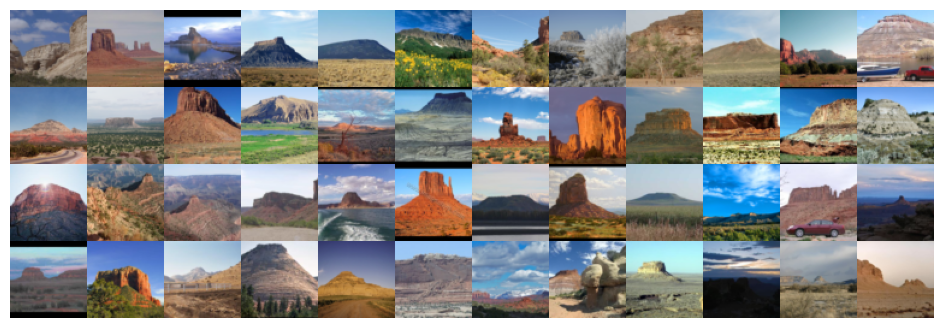

In [7]:
import torchvision.transforms as T
import numpy as np
import matplotlib.pyplot as plt

category = "/b/butte"
trainset = SUN20(split="train")

imgs = []
for i in range(len(trainset)):
    img, label = trainset[i]
    if trainset.categories[label] == category:
        imgs.append(img)
    if len(imgs) == 48:
        break

print(f"Collected {len(imgs)} images for category {category}")

# Safety check (optional but good practice)
assert len(imgs) >= 48, "Not enough images found for category!"

transform = T.Compose([
    T.CenterCrop(min(imgs[0].size)),
    T.Resize((64, 64))
])

imgs = [transform(im) for im in imgs]

grid = np.zeros((4*64, 12*64, 3), dtype=np.uint8)

for idx, im in enumerate(imgs):
    r = idx // 12
    c = idx % 12
    grid[r*64:(r+1)*64, c*64:(c+1)*64] = np.array(im)

plt.figure(figsize=(12,4))
plt.imshow(grid)
plt.axis("off")
plt.show()

**Note:** Hopefully after visualzing the category `butte` you can visualize what this word really means.

# **2. Linear Classifiers**

In this section we explore how to define and use **linear classifiers** for image classification on the **SUN20** dataset. A linear classifier predicts a score for each class using a single affine transformation of the input features.

Because linear classifiers operate on **fixed-length vectors**, images must be converted into vectors of the same dimensionality before being passed to the model.


#### **2.1 Defining a Linear Classifier**


A multi-class linear classifier computes class scores (also called *logits*) as

$$
\text{logits} = W x + b$$

where \(x\) is the input feature vector, \(W\) is a weight matrix, and \(b\) is a bias term.

In PyTorch, models inherit from `torch.nn.Module` and implement a `forward()` method. The `forward()` method should return **raw logits**. When training, we will use `nn.CrossEntropyLoss`, which internally applies the softmax operation, so the model itself should *not* apply softmax.

To use a linear classifier for images, we resize each image to **32×32**, convert it to a tensor, and flatten it into a vector of length \(32 \times 32 \times 3 = 3072\).

Below we define a simple linear classifier and inspect its predictions on a random input.

In [9]:
import torch
import torch.nn as nn

# Define a linear classifier (single-layer neural network).
# The model maps an input feature vector to one score per class.
class LinearClassifier(nn.Module):
    def __init__(self, input_size, num_classes):
        super().__init__()
        self.linear = nn.Linear(input_size, num_classes)

    def forward(self, x):
        # Return raw class scores (logits)
        return self.linear(x)

# Instantiate the classifier
input_size = 32 * 32 * 3
num_classes = len(trainset.categories)
model = LinearClassifier(input_size, num_classes)

# Create a dummy input vector (batch size = 1)
dummy_input = torch.rand(1, input_size)

# Forward pass
logits = model(dummy_input)
probabilities = torch.softmax(logits, dim=1)

# Display predicted probabilities
for i, category in enumerate(trainset.categories):
    print(f'P("{category}") = {probabilities[0, i].item():.2f}')


P("/a/arch") = 0.04
P("/b/bathroom") = 0.02
P("/b/butte") = 0.04
P("/d/dentists_office") = 0.07
P("/h/hot_spring") = 0.06
P("/j/jacuzzi/indoor") = 0.08
P("/l/laundromat") = 0.06
P("/l/lecture_room") = 0.04
P("/l/library/indoor") = 0.06
P("/l/lighthouse") = 0.05
P("/l/living_room") = 0.06
P("/m/mansion") = 0.03
P("/m/marsh") = 0.06
P("/m/mountain") = 0.04
P("/s/sauna") = 0.06
P("/s/shower") = 0.05
P("/s/skyscraper") = 0.04
P("/t/tower") = 0.06
P("/t/tree_house") = 0.04
P("/v/volcano") = 0.04


#### **2.2 Stochastic Gradient Descent (SGD) Loop**


In this section we train the linear classifier from **2.1** using **mini-batch Stochastic Gradient Descent (SGD)**.

The training code below implements the standard PyTorch workflow:

- Move the model (and data) to the appropriate device (**CPU** or **GPU**)
- Iterate over the training set for multiple **epochs**
- For each mini-batch:
  - compute **logits** (model outputs)
  - compute the **loss**
  - run **backpropagation** (`loss.backward()`)
  - update parameters with the optimizer (`optimizer.step()`)

We also evaluate the model on a **validation set** at the end of each epoch to track generalization performance and save the model checkpoint that achieves the best validation accuracy.

Please read the code carefully. If you do not understand what a line does, ask on the discussion forum or during office hours—being able to explain each step in the training loop is an important learning objective for this assignment.

In [18]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def train_model(
    model,
    cost_function,
    optimizer,
    train_loader,
    val_loader,
    n_epochs=10,
    scheduler=None,
    save_path="best_model_so_far.pth",
    use_livelossplot=True,
):
    # Optional live plotting
    liveloss = None
    if use_livelossplot:
        from livelossplot import PlotLosses
        liveloss = PlotLosses()

    model = model.to(device)
    best_val_acc = 0.0

    for epoch in range(n_epochs):
        logs = {}

        # --------------------
        # Train
        # --------------------
        model.train()
        correct = 0
        total = 0
        loss_sum = 0.0  # sum of (loss * batch_size)

        for xb, yb in train_loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            logits = model(xb)
            loss = cost_function(logits, yb)

            loss.backward()
            optimizer.step()

            bs = xb.size(0)
            loss_sum += loss.item() * bs
            total += bs
            correct += (logits.argmax(dim=1) == yb).sum().item()

        logs["loss"] = loss_sum / total
        logs["accuracy"] = correct / total

        # --------------------
        # Validate
        # --------------------
        model.eval()
        correct = 0
        total = 0
        loss_sum = 0.0

        with torch.inference_mode():
            for xb, yb in val_loader:
                xb = xb.to(device, non_blocking=True)
                yb = yb.to(device, non_blocking=True)

                logits = model(xb)
                loss = cost_function(logits, yb)

                bs = xb.size(0)
                loss_sum += loss.item() * bs
                total += bs
                correct += (logits.argmax(dim=1) == yb).sum().item()

        logs["val_loss"] = loss_sum / total
        logs["val_accuracy"] = correct / total

        # Save best model
        if logs["val_accuracy"] > best_val_acc:
            best_val_acc = logs["val_accuracy"]
            torch.save(model.state_dict(), save_path)

        # Update plot
        if liveloss is not None:
            liveloss.update(logs)
            liveloss.send()

        # Step scheduler (if any)
        if scheduler is not None:
            # Some schedulers (ReduceLROnPlateau) expect a metric
            try:
                scheduler.step(logs["val_loss"])
            except TypeError:
                scheduler.step()

        print(
            f"Epoch {epoch+1}/{n_epochs} | "
            f"loss={logs['loss']:.4f}, acc={logs['accuracy']:.4f} | "
            f"val_loss={logs['val_loss']:.4f}, val_acc={logs['val_accuracy']:.4f}"
        )

    # Optionally load best weights at end
    # model.load_state_dict(torch.load(save_path, map_location=device))

    return best_val_acc


#### **2.3 Training our Linear Classifier**


In this section we train our `LinearClassifier` on SUN20 using PyTorch `DataLoader`s to create mini-batches.

Key points to observe:

- **Transforms** are applied inside the dataset class to ensure each image becomes a fixed-length vector suitable for a linear classifier:
  - resize to **32×32**
  - convert to a tensor
  - **flatten** into a vector of length $32 \cdot 32 \cdot 3 = 3072$

- We use `CrossEntropyLoss`, which expects **raw logits** from the model and applies the softmax internally.

- The `DataLoader` handles batching and optional shuffling of the training set.

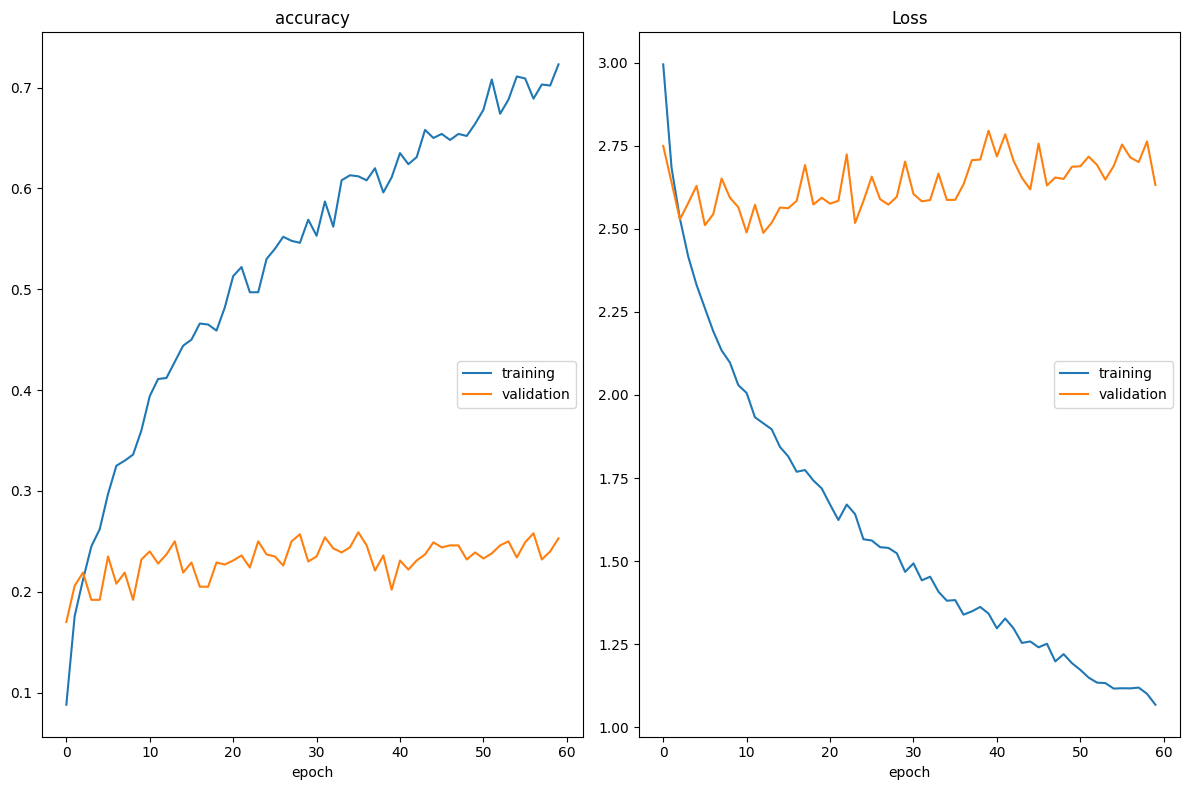

accuracy
	training         	 (min:    0.088, max:    0.723, cur:    0.723)
	validation       	 (min:    0.170, max:    0.259, cur:    0.253)
Loss
	training         	 (min:    1.068, max:    2.996, cur:    1.068)
	validation       	 (min:    2.488, max:    2.796, cur:    2.632)
Epoch 60/60 | loss=1.0675, acc=0.7230 | val_loss=2.6322, val_acc=0.2530


0.259

In [11]:
import torch
import torch.optim
import torchvision.transforms as transforms

batch_size = 16
n_epochs = 60
learning_rate = 1e-3

# Preprocessing: resize -> tensor -> flatten to 3072-dim vector
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))  # flatten (3,32,32) -> (3072,)
])

# Datasets / loaders
trainset = SUN20(split="train", transform=transform)
valset   = SUN20(split="val",   transform=transform)

train_loader = torch.utils.data.DataLoader(
    trainset,
    batch_size=8,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = torch.utils.data.DataLoader(
    valset,
    batch_size=8,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

# Model / loss / optimizer
model = LinearClassifier(32 * 32 * 3, len(trainset.categories))

# CrossEntropyLoss expects logits and applies softmax internally
cost_function = torch.nn.CrossEntropyLoss()

# SGD baseline (optionally add momentum for faster convergence)
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)

# Train
train_model(
    model=model,
    cost_function=cost_function,
    optimizer=optimizer,
    train_loader=train_loader,
    val_loader=val_loader,
    n_epochs=n_epochs,
    scheduler=None,
    use_livelossplot=True,
)


You can observe that this model is **learning the task**: the training loss decreases over time, and the accuracy steadily improves. Importantly, the validation loss also decreases and the validation accuracy increases, indicating that the model is not simply memorizing the training data.

Despite being a very simple model—a **linear classifier operating on raw pixel values**—it is able to achieve an accuracy of approximately **26%**, and the training appears to be converging.

This performance is far from state-of-the-art, but it is significantly better than chance.


**Question:**  

What accuracy would you expect from **random guessing** on this task? How does that baseline compare to the performance of the linear classifier?

**Answer:**

The SUN20 dataset contains 20 scene categories.
If predictions are made by random guessing, Each class has probability 1/20, so the expected accuracy from random guessing is 5%.

The trained linear classifier achieves approximately 25-27% validation accuracy, which is significantly higher than random guessing. This shows that, despite its simplicity and lack of spatial modeling, the linear classifier is able to learn meaningful statistical regularities from the data.

However, its performance is still limited because flattening raw pixels removes spatial structure, preventing the model from capturing higher-level visual patterns necessary for strong generalization. This gap between random guessing and linear classifier performance motivates the use of convolutional neural networks in later sections.

#### **2.4 Qualitative Evaluation on Validation Data**

So far, we have evaluated our linear classifier using **aggregate metrics** such as loss and accuracy. While these metrics are important, they do not tell the full story.

In this section, we will **inspect the model’s predictions on individual validation images**. Visualizing predictions helps us understand:
- what the model gets right,
- what it gets wrong,
- and *why* a simple linear model may struggle with complex visual scenes.

We will display a small number of validation images along with:
- the **ground-truth category**, and
- the **model’s predicted category**.


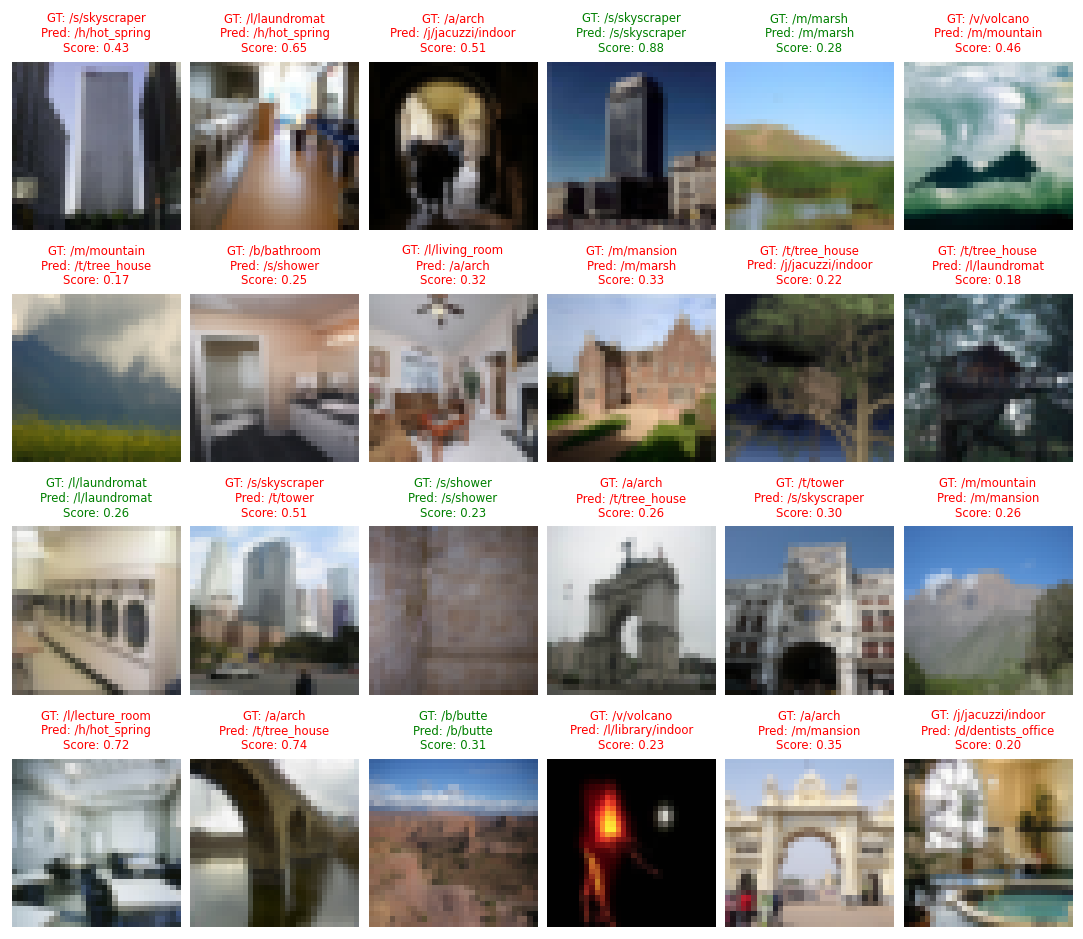

In [12]:
import random
import math
import matplotlib.pyplot as plt
import torch.nn.functional as F

model.eval()

# Number of examples to visualize
n_show = 24
n_cols = 6
n_rows = math.ceil(n_show / n_cols)

# Randomly sample validation indices
indices = random.sample(range(len(valset)), n_show)

# Load samples
xb, yb = zip(*(valset[i] for i in indices))
xb = torch.stack(xb).to(device)
yb = torch.tensor(yb).to(device)

with torch.no_grad():
    logits = model(xb)
    probs = F.softmax(logits, dim=1)
    scores, preds = probs.max(dim=1)

plt.figure(figsize=(1.5 * n_cols, 2 * n_rows), dpi=120)

for i in range(n_show):
    img = xb[i].cpu().view(3, 32, 32).permute(1, 2, 0)

    gt = trainset.categories[yb[i]]
    pr = trainset.categories[preds[i]]
    sc = scores[i].item()
    color = "green" if gt == pr else "red"

    ax = plt.subplot(n_rows, n_cols, i + 1)
    ax.imshow(img, interpolation="nearest")
    ax.axis("off")
    ax.set_title(
        f"GT: {gt}\nPred: {pr}\nScore: {sc:.2f}",
        color=color,
        fontsize=7
    )

plt.tight_layout(pad=0.6)
plt.show()


# **3. Convolutional Neural Networks (CNNs)**

The linear classifier from the previous section operates on **flattened pixel values** and ignores the spatial structure of images. As a result, its performance is limited.

In this section, we define a **Convolutional Neural Network (CNN)** that processes images as 2D spatial signals. CNNs exploit local spatial structure through **convolution**, **non-linearities**, and **pooling**, making them far more effective for visual recognition tasks.

The CNN defined below expects input images of size **48×48×3** and produces a score for each of the SUN20 categories.


In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ConvnetClassifier(nn.Module):
    def __init__(self):
        super().__init__()

        # Convolutional layers
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=128, kernel_size=5)
        self.conv2 = nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3)

        # Fully connected layers
        self.linear1 = nn.Linear(128 * 10 * 10, 256)
        self.linear2 = nn.Linear(256, 20)

    def forward(self, x):
        # Input: (B, 3, 48, 48)

        x = F.relu(F.max_pool2d(self.conv1(x), 2))
        # After conv1 + pool: (B, 128, 22, 22)

        x = F.relu(F.max_pool2d(self.conv2(x), 2))
        # After conv2 + pool: (B, 128, 10, 10)

        # Flatten spatial dimensions
        x = x.view(x.size(0), -1)  # (B, 128*10*10)

        # Fully connected layers
        x = F.relu(self.linear1(x))
        x = self.linear2(x)        # logits

        return x


# Sanity check: forward pass with dummy data
dummy_batch = torch.zeros(24, 3, 48, 48)
model = ConvnetClassifier()
predictions = model(dummy_batch)

print("Input shape :", dummy_batch.shape)
print("Output shape:", predictions.shape)

Input shape : torch.Size([24, 3, 48, 48])
Output shape: torch.Size([24, 20])


# **Questions** **[8pts]**

#### **A.0 Preliminaries: Curve Fitting with PyTorch Autograd** **[2pts]**



In this warm-up, you will use **PyTorch autograd** to fit a polynomial function to a small set of 1D data points.

You will optimize **six scalar parameters** $w_1,\dots,w_5$ and $b$ in the model:

$$
y = f(x) = w_1 x + w_2 x^2 + w_3 x^3 + w_4 x^4 + w_5 x^5 + b
$$

Your goal is to minimize the **mean of squared errors** over the provided data points:

$$
L(w_1,\dots,w_5,b) = \frac{1}{N}\sum_i^N \left(y_i - f(x_i)\right)^2
$$

---

##### **What you need to do**
1. Represent the parameters $w_1,\dots,w_5,b$ as PyTorch tensors with `requires_grad=True`.
2. Implement the forward computation $f(x)$.
3. Use gradient-based optimization (e.g., **SGD**, **Adam**, or others) to minimize the loss $L$.
4. Print the learned values of $w_1,\dots,w_5$ and $b$.
5. Sample random $x$ values uniformly from $[0,1]$, evaluate $f(x)$, and plot the fitted curve **on top of the original data points**.

---

##### **Deliverables**
- A code cell that runs end-to-end and prints the learned parameters.
- A plot showing:
  - the original $(x_i, y_i)$ data points, and
  - the fitted polynomial curve evaluated on random inputs $x \sim U(0,1)$.

---

##### **Submission**
Record your final parameters and final loss value in this spreadsheet:  
[Spreadsheet](https://docs.google.com/spreadsheets/d/1QleUdS0K2cVF7JJ9jfHZ_HAF-_8I9CglGCVb4pphxhc/edit?usp=sharing)

---

##### **Grading**
- **[1pt]** Correct use of PyTorch autograd to optimize the parameters and produce a valid fitted curve

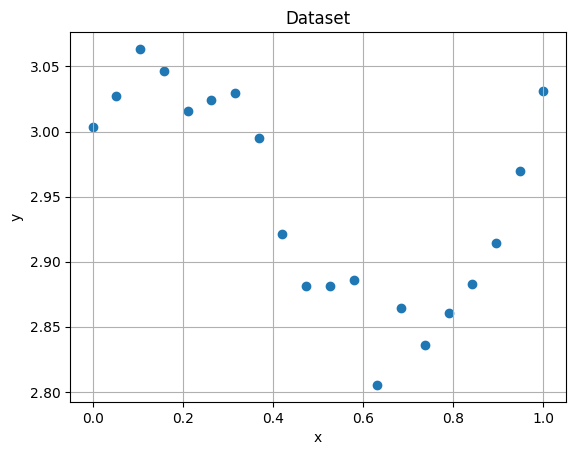

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch

# Hard-coded dataset
data = np.array([
    [0.00000000, 3.00377202],
    [0.05263158, 3.02735591],
    [0.10526316, 3.06346607],
    [0.15789473, 3.04628515],
    [0.21052632, 3.01568294],
    [0.26315790, 3.02421117],
    [0.31578946, 3.02988410],
    [0.36842105, 2.99473572],
    [0.42105263, 2.92091560],
    [0.47368422, 2.88156033],
    [0.52631581, 2.88146281],
    [0.57894737, 2.88627911],
    [0.63157892, 2.80529881],
    [0.68421054, 2.86435413],
    [0.73684210, 2.83587027],
    [0.78947371, 2.86059833],
    [0.84210527, 2.88303900],
    [0.89473683, 2.91466379],
    [0.94736844, 2.96982837],
    [1.00000000, 3.03127599],
], dtype=np.float32)


# Scatter plot of the data
plt.scatter(data[:, 0], data[:, 1], label='Original Data')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.title('Dataset')
plt.show()



We provide here some starting code, please complete the code using your knowledge of Pytorch.

w_1=0.690402, w_2=-2.574815, w_3=0.229000, w_4=3.476393, w_5=-1.795664, b=3.003120
final_loss=0.000330999524059


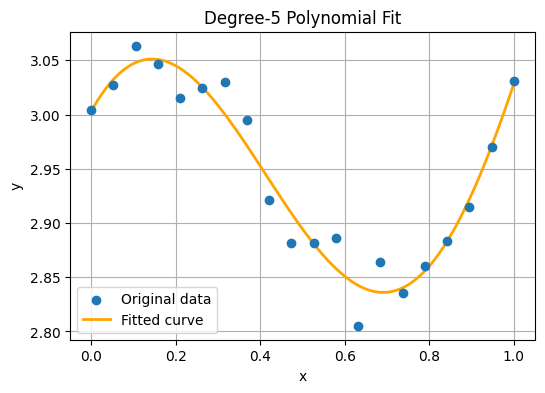

In [ ]:
import torch
import matplotlib.pyplot as plt

# Model: y = w1*x + w2*x^2 + w3*x^3 + w4*x^4 + w5*x^5 + b
def f(w_1, w_2, w_3, w_4, w_5, b, x):
    return w_1*x + w_2*x**2 + w_3*x**3 + w_4*x**4 + w_5*x**5 + b

# Loss (MSE)
def L(y, y_pred):
    return torch.mean((y - y_pred) ** 2)

# Convert data to float64 for maximum precision
x_data = torch.tensor(data[:, 0], dtype=torch.float64)
y_data = torch.tensor(data[:, 1], dtype=torch.float64)

# Precompute powers
x1, x2, x3, x4, x5 = x_data, x_data**2, x_data**3, x_data**4, x_data**5

# Six scalar parameters with requires_grad=True
w_1 = torch.zeros(1, dtype=torch.float64, requires_grad=True)
w_2 = torch.zeros(1, dtype=torch.float64, requires_grad=True)
w_3 = torch.zeros(1, dtype=torch.float64, requires_grad=True)
w_4 = torch.zeros(1, dtype=torch.float64, requires_grad=True)
w_5 = torch.zeros(1, dtype=torch.float64, requires_grad=True)
b   = torch.zeros(1, dtype=torch.float64, requires_grad=True)

# L-BFGS optimizer (lr=1.0 is natural for L-BFGS, tightest tolerances)
optimizer = torch.optim.LBFGS(
    [w_1, w_2, w_3, w_4, w_5, b],
    lr=1.0,
    max_iter=10000,
    max_eval=20000,
    tolerance_grad=1e-15,
    tolerance_change=1e-15,
    history_size=100,
    line_search_fn="strong_wolfe",
)

def closure():
    optimizer.zero_grad()
    y_pred = w_1*x1 + w_2*x2 + w_3*x3 + w_4*x4 + w_5*x5 + b
    loss = L(y_data, y_pred)
    loss.backward()
    return loss

optimizer.step(closure)
final_loss = closure().item()

print(f"w_1={w_1.item():.6f}, w_2={w_2.item():.6f}, w_3={w_3.item():.6f}, "
      f"w_4={w_4.item():.6f}, w_5={w_5.item():.6f}, b={b.item():.6f}")
print(f"final_loss={final_loss:.15f}")

# Plot: random x in [0,1], sorted for smooth curve
xx = torch.rand(300, dtype=torch.float64)
xx, _ = torch.sort(xx)
yy = f(w_1, w_2, w_3, w_4, w_5, b, xx).detach().numpy()

plt.figure(figsize=(6, 4))
plt.scatter(data[:, 0], data[:, 1], label="Original data", zorder=5)
plt.plot(xx.numpy(), yy, color="orange", label="Fitted curve", linewidth=2)
plt.xlabel("x"); plt.ylabel("y")
plt.grid(True); plt.legend(); plt.title("Degree-5 Polynomial Fit")
plt.show()

#### **A.1 Train the Convolutional Neural Network in Section 3** **[1pt]**


Section 3 provides a simple convolutional neural network (CNN) architecture, but does not show how to train it. In this section, you will write the training code needed to train that CNN on the SUN20 dataset.

You may **re-use and adapt** code from Sections **2** and **3** (e.g., the SGD loop, loss function, optimizer, and dataloaders). The most important part is to correctly:

- set up the **data transforms** so images are tensors of shape **(3, 48, 48)** (the CNN input size),
- create appropriate **DataLoaders**: `train_loader` and `val_loader`,
- choose reasonable training hyperparameters:
  - batch size,
  - number of epochs,
  - learning rate,
  - optimizer (SGD/Adam),
  - (optional) learning-rate scheduler.

Your training cell(s) must also print the training and validation metrics (loss and accuracy) so that the output appears directly in the notebook.

A correct implementation should achieve a validation accuracy similar to the sample output (approximately the same range) to receive full credit.

**Note:** To earn points, your notebook must include **both the code and the printed output** (and/or plots) from running the training procedure. Submitting only code without output will not receive credit.

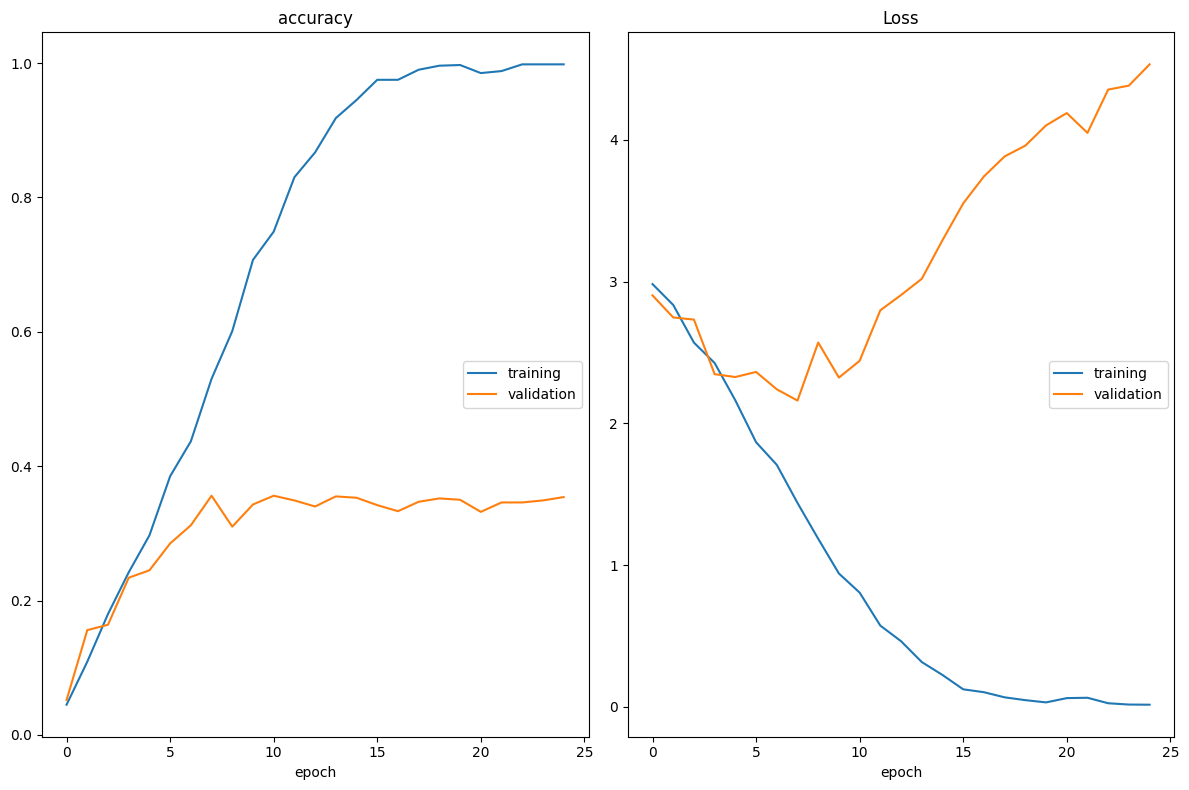

accuracy
	training         	 (min:    0.045, max:    0.998, cur:    0.998)
	validation       	 (min:    0.052, max:    0.356, cur:    0.354)
Loss
	training         	 (min:    0.015, max:    2.982, cur:    0.015)
	validation       	 (min:    2.161, max:    4.532, cur:    4.532)
Epoch 25/25 | loss=0.0153, acc=0.9980 | val_loss=4.5325, val_acc=0.3540


0.356

In [18]:
transform_a1 = transforms.Compose([
    transforms.Resize((48,48)),
    transforms.ToTensor()
])

trainset_a1 = SUN20("train", transform_a1)
valset_a1   = SUN20("val", transform_a1)

train_loader_a1 = torch.utils.data.DataLoader(trainset_a1, batch_size=32, shuffle=True)
val_loader_a1   = torch.utils.data.DataLoader(valset_a1, batch_size=32)

model_a1 = ConvnetClassifier()
optimizer_a1 = torch.optim.Adam(model_a1.parameters(), lr=1e-3)
loss_fn_a1 = nn.CrossEntropyLoss()

train_model(
    model_a1,
    loss_fn_a1,
    optimizer_a1,
    train_loader_a1,
    val_loader_a1,
    n_epochs=25,
    save_path="best_model_a1.pth"
)

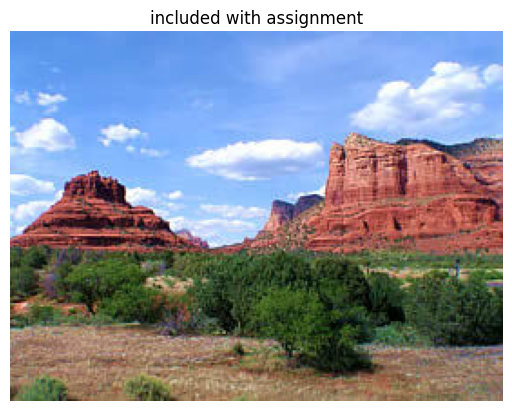

P("/a/arch") = 0.00
P("/b/bathroom") = 0.00
P("/b/butte") = 0.99
P("/d/dentists_office") = 0.00
P("/h/hot_spring") = 0.00
P("/j/jacuzzi/indoor") = 0.00
P("/l/laundromat") = 0.00
P("/l/lecture_room") = 0.00
P("/l/library/indoor") = 0.00
P("/l/lighthouse") = 0.00
P("/l/living_room") = 0.00
P("/m/mansion") = 0.00
P("/m/marsh") = 0.00
P("/m/mountain") = 0.00
P("/s/sauna") = 0.00
P("/s/shower") = 0.00
P("/s/skyscraper") = 0.00
P("/t/tower") = 0.00
P("/t/tree_house") = 0.00
P("/v/volcano") = 0.00


In [19]:
# Including an example prediction just for your reference to see the model is really working.

import matplotlib.pyplot as plt

input_image_id = 113

# Load the validation set WITHOUT transform (returns PIL images)
valset_a1_raw = SUN20(split='val')

# Sample
x, y = valset_a1_raw[input_image_id]

# Process input and add a dummy batch dimension.
xp = transform_a1(x)[None, :].to(device)

predictions_a1 = model_a1(xp).softmax(dim=1)

plt.figure(); plt.title("included with assignment"); plt.imshow(x); plt.axis(False); plt.show()

# Show predictions from this model.
for i in range(0, len(trainset_a1.categories)):
    score = predictions_a1[0, i].item()
    category = trainset_a1.categories[i]
    print('P("{0}") = {1:.2f}'.format(category, score))

#### **A.2 Show results from the previously trained model** **[1pt]**


We run the trained CNN on the validation set and retrieve the **top 20 images** with the highest predicted probability for the class **`butte`**.  
Each tile shows `P[butte]`. We draw a **green** border if the ground-truth label is `butte`, and **red** otherwise.

**Grading:**
* Your output should closely match what is shown here.

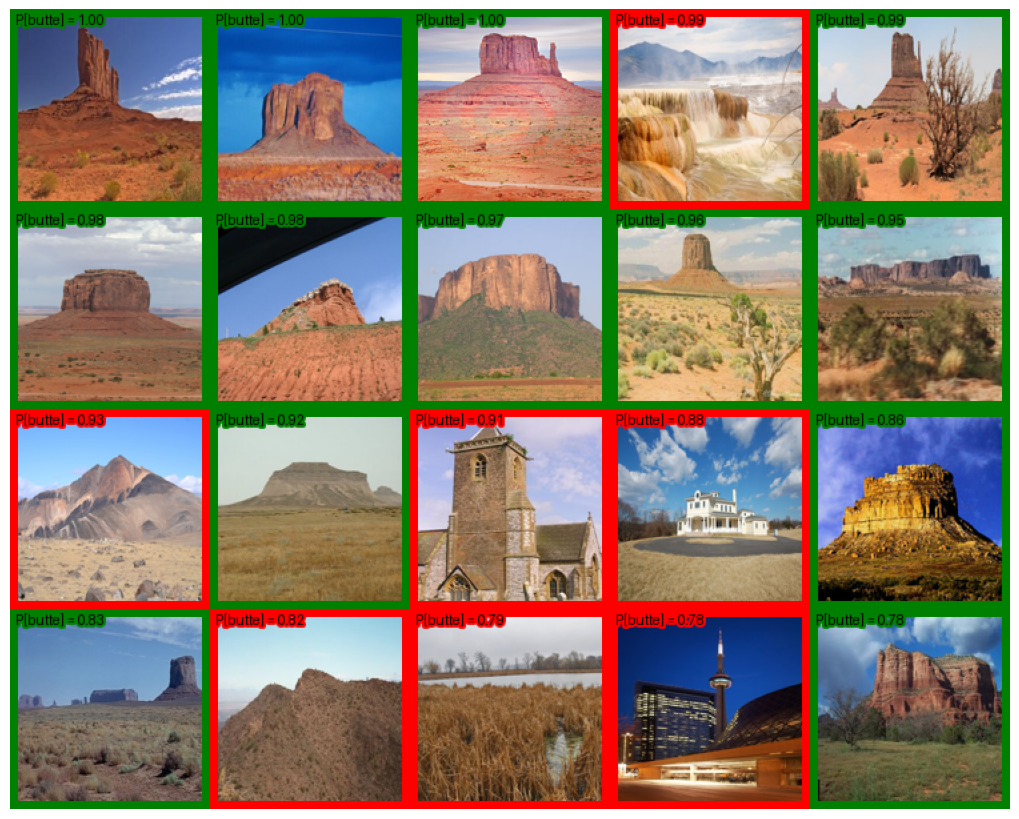

In [20]:
from PIL import Image, ImageDraw, ImageFont

butte_idx = trainset_a1.categories.index("/b/butte")
scores_a2 = []

model_a1.load_state_dict(torch.load("best_model_a1.pth", map_location=device))
model_a1.eval()

valset_a2 = SUN20(split='val')

with torch.no_grad():
    for i in range(len(valset_a2)):
        x, y = valset_a2[i]
        p = model_a1(transform_a1(x).unsqueeze(0).to(device)).softmax(1)[0, butte_idx]
        scores_a2.append((p.item(), i, y))

top20 = sorted(scores_a2, reverse=True)[:20]

# --- Stitch into a single image with zero gaps ---
TILE   = 150       # each tile size (square)
BORDER = 6         # border thickness in pixels
ROWS, COLS = 4, 5

canvas = Image.new("RGB", (COLS * TILE, ROWS * TILE))
draw   = ImageDraw.Draw(canvas)

for i, (p, idx, y) in enumerate(top20):
    img, _ = valset_a2[idx]
    img = img.resize((TILE, TILE))               # force square

    row, col = i // COLS, i % COLS
    x0, y0 = col * TILE, row * TILE
    canvas.paste(img, (x0, y0))

    # Draw colored border directly on the image
    color = "green" if y == butte_idx else "red"
    for b in range(BORDER):
        draw.rectangle([x0 + b, y0 + b, x0 + TILE - 1 - b, y0 + TILE - 1 - b], outline=color)

    # Draw text label on the image
    label = f"P[butte] = {p:.2f}"
    draw.text((x0 + 4, y0 + 2), label, fill="black",
              stroke_width=2, stroke_fill=color)

plt.figure(figsize=(10, 8))
plt.imshow(canvas)
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()

#### **A.3 Define and Train a Better Convolutional Neural Network** **[2pts]**



The ConvNet from Section 3 / A.1 reaches only ~30% validation accuracy.  
In this section, design and train an improved CNN that achieves **at least 54.2% maximum validation accuracy** on the validation set.

You may improve performance by:
- modifying the network architecture (more layers, more channels),
- adding Batch Normalization and/or Dropout,
- using data augmentation,
- tuning optimization parameters (learning rate, batch size, optimizer),
- training at a higher image resolution than 48×48.

---

##### **Requirements**
Your notebook must show:
- the definition of your improved CNN,
- the training code and printed training output,
- the **maximum validation accuracy** achieved.

You must also report:
- number of trainable parameters,
- training time,
- maximum validation accuracy,

in this spreadsheet:
[Spreadsheet](https://docs.google.com/spreadsheets/d/1nixl0xPziEQvqltLeKQqj403PCuNOQRelGJRcoVvPNQ/edit?usp=sharing)

---

##### **Requirement**
- Validation accuracy ≥ **54.2%** with required information reported.

In [32]:
import time, math, random
import torch, torch.nn as nn
from torchvision import transforms

dev = "cuda" if torch.cuda.is_available() else "cpu"

# ╔══════════════════════════════════════════════════════════════╗
# ║  CONFIG (we'll tune this later)                              ║
# ╚══════════════════════════════════════════════════════════════╝
W           = 56                # base width
DEPTHS      = [3, 4, 6, 3]     # blocks per stage
FINAL_MULT  = 8                 # final channel multiplier
IMG         = 224               # input resolution
EPOCHS      = 400
BATCH       = 100
LR          = 4e-4
WD          = 9e-3
DROP_PATH   = 0.0              # stochastic depth rate
DROPOUT     = 0.01
LABEL_SMOOTH= 0.15
EMA_DECAY   = 0.999
CUTMIX_ALPHA= 1.0

mu, sig = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225)

# ╔══════════════════════════════════════════════════════════════╗
# ║  TECHNIQUE 1: Strong Data Augmentation + RandAugment         ║
# ╚══════════════════════════════════════════════════════════════╝
train_tf = transforms.Compose([
    transforms.Resize(int(IMG * 1.2), interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.RandomResizedCrop(IMG, scale=(0.5, 1.0), interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.RandomHorizontalFlip(),
    transforms.RandAugment(num_ops=2, magnitude=9),       # ← RandAugment
    transforms.ToTensor(),
    transforms.Normalize(mu, sig),
    transforms.RandomErasing(p=0.25),                      # ← Random erasing
])
val_tf = transforms.Compose([
    transforms.Resize(int(IMG * 1.15), interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.CenterCrop(IMG),
    transforms.ToTensor(),
    transforms.Normalize(mu, sig),
])

tr_ds = SUN20("train", train_tf)
va_ds = SUN20("val", val_tf)
tr_dl = torch.utils.data.DataLoader(tr_ds, BATCH, True,  num_workers=2, pin_memory=(dev=="cuda"))
va_dl = torch.utils.data.DataLoader(va_ds, 64,    False, num_workers=2, pin_memory=(dev=="cuda"))

# ╔══════════════════════════════════════════════════════════════╗
# ║  TECHNIQUE 2: Squeeze-and-Excitation (channel attention)     ║
# ╚══════════════════════════════════════════════════════════════╝
class SE(nn.Module):
    """Learn per-channel importance weights. Adds <1% params but +3-5% acc."""
    def __init__(self, c, r=16):
        super().__init__()
        mid = max(c // r, 8)
        self.net = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(c, mid), nn.ReLU(inplace=True),
            nn.Linear(mid, c), nn.Sigmoid(),
        )
    def forward(self, x):
        return x * self.net(x).view(-1, x.size(1), 1, 1)

# ╔══════════════════════════════════════════════════════════════╗
# ║  TECHNIQUE 3: Stochastic Depth (drop entire residual blocks) ║
# ╚══════════════════════════════════════════════════════════════╝
class DropPath(nn.Module):
    """Randomly skip residual blocks during training → implicit ensemble."""
    def __init__(self, p=0.0):
        super().__init__()
        self.p = p
    def forward(self, x):
        if not self.training or self.p == 0: return x
        keep = 1 - self.p
        mask = torch.rand(x.size(0), 1, 1, 1, device=x.device) < keep
        return x * mask / keep

# ╔══════════════════════════════════════════════════════════════╗
# ║  MODEL: ResNet blocks + SE + DropPath                        ║
# ╚══════════════════════════════════════════════════════════════╝
class Block(nn.Module):
    def __init__(self, c1, c2, stride=1, drop_path=0.0):
        super().__init__()
        self.f = nn.Sequential(
            nn.Conv2d(c1, c2, 3, stride, 1, bias=False), nn.BatchNorm2d(c2), nn.ReLU(True),
            nn.Conv2d(c2, c2, 3, 1,      1, bias=False), nn.BatchNorm2d(c2),
            SE(c2),                                        # ← SE attention
        )
        self.skip = (nn.Identity() if (c1 == c2 and stride == 1)
                     else nn.Sequential(nn.Conv2d(c1, c2, 1, stride, bias=False), nn.BatchNorm2d(c2)))
        self.dp = DropPath(drop_path)                      # ← stochastic depth

    def forward(self, x):
        return torch.relu_(self.dp(self.f(x)) + self.skip(x))

def make_stage(c1, c2, n, stride, dp_rates):
    return nn.Sequential(Block(c1, c2, stride, dp_rates[0]),
                         *[Block(c2, c2, 1, dp_rates[i]) for i in range(1, n)])

class BetterCNN(nn.Module):
    def __init__(self, w, depths, final_mult, drop_path=0.2, dropout=0.4, num_classes=20):
        super().__init__()
        total = sum(depths)
        dp = [x.item() for x in torch.linspace(0, drop_path, total)]  # linearly increase
        self.stem = nn.Sequential(
            nn.Conv2d(3, w, 7, 2, 3, bias=False), nn.BatchNorm2d(w), nn.ReLU(True),
            nn.MaxPool2d(3, 2, 1),
        )
        channels = [w, w, 2*w, 4*w, final_mult*w]
        i = 0
        stages = []
        for s, d in enumerate(depths):
            stages.append(make_stage(channels[s], channels[s+1], d, 1 if s==0 else 2, dp[i:i+d]))
            i += d
        self.stages = nn.Sequential(*stages)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Linear(channels[-1], num_classes)

    def forward(self, x):
        return self.fc(self.drop(self.pool(self.stages(self.stem(x))).flatten(1)))

model = BetterCNN(W, DEPTHS, FINAL_MULT, DROP_PATH, DROPOUT, len(tr_ds.categories)).to(dev)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,}")

# ╔══════════════════════════════════════════════════════════════╗
# ║  TECHNIQUE 4: EMA (Exponential Moving Average of weights)    ║
# ╚══════════════════════════════════════════════════════════════╝
class EMA:
    """Smoothed copy of weights → more stable eval, +1-2% acc."""
    def __init__(self, mdl, decay=0.999):
        self.d = decay
        self.shadow = {k: v.clone() for k, v in mdl.state_dict().items() if v.is_floating_point()}
    @torch.no_grad()
    def update(self, mdl):
        for k, v in mdl.state_dict().items():
            if k in self.shadow: self.shadow[k].mul_(self.d).add_(v, alpha=1-self.d)
    @torch.no_grad()
    def apply(self, mdl):
        self.bk = {k: v.clone() for k, v in mdl.state_dict().items() if k in self.shadow}
        for k in self.shadow: mdl.state_dict()[k].copy_(self.shadow[k])
    @torch.no_grad()
    def restore(self, mdl):
        for k in self.bk: mdl.state_dict()[k].copy_(self.bk[k])

# ema = EMA(model, EMA_DECAY)

# ╔══════════════════════════════════════════════════════════════╗
# ║  TECHNIQUE 5: CutMix + MixUp (50/50 random)                 ║
# ╚══════════════════════════════════════════════════════════════╝
def cutmix_or_mixup(x, y, alpha=1.0):
    """Mix training samples → stronger regularization, +3-5% acc."""
    lam = torch.distributions.Beta(alpha, alpha).sample().item()
    idx = torch.randperm(x.size(0), device=x.device)
    if random.random() < 0.5:  # CutMix: paste a patch
        r = math.sqrt(1 - lam); W, H = x.size(3), x.size(2)
        cx, cy = random.randint(0, W-1), random.randint(0, H-1)
        hw, hh = int(W*r)//2, int(H*r)//2
        x1, y1_, x2, y2_ = max(cx-hw,0), max(cy-hh,0), min(cx+hw,W), min(cy+hh,H)
        x[:,:,y1_:y2_,x1:x2] = x[idx,:,y1_:y2_,x1:x2]
        lam = 1 - (x2-x1)*(y2_-y1_)/(W*H)
    else:  # MixUp: blend images
        x = lam * x + (1 - lam) * x[idx]
    return x, y, y[idx], lam

# ╔══════════════════════════════════════════════════════════════╗
# ║  TECHNIQUE 6: Label Smoothing + Cosine Annealing             ║
# ╚══════════════════════════════════════════════════════════════╝
loss_fn = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTH)
opt     = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)
sched   = torch.optim.lr_scheduler.CosineAnnealingLR(opt, EPOCHS, eta_min=1e-5)

# ╔══════════════════════════════════════════════════════════════╗
# ║  TECHNIQUE 7: Flip TTA (Test-Time Augmentation) at eval      ║
# ╚══════════════════════════════════════════════════════════════╝
@torch.no_grad()
def evaluate():
    """Average predictions over original + horizontally flipped → +0.5-1.5% acc."""
    model.eval(); c = t = 0
    for x, y in va_dl:
        x, y = x.to(dev), y.to(dev)
        logits = model(x) + model(torch.flip(x, [3]))     # ← flip TTA
        c += (logits.argmax(1) == y).sum().item(); t += y.size(0)
    return c / t

# ╔══════════════════════════════════════════════════════════════╗
# ║  TRAINING LOOP                                               ║
# ╚══════════════════════════════════════════════════════════════╝
best = 0; t0 = time.time()
for e in range(EPOCHS):
    model.train()
    for x, y in tr_dl:
        x, y = x.to(dev), y.to(dev)
        x, y1, y2, lam = cutmix_or_mixup(x, y, CUTMIX_ALPHA)  # ← CutMix/MixUp
        opt.zero_grad(set_to_none=True)
        out = model(x)
        (lam * loss_fn(out, y1) + (1-lam) * loss_fn(out, y2)).backward()
        opt.step()
        # ema.update(model)                                        # ← EMA update
    sched.step()

    # ema.apply(model); 
    acc = evaluate(); 
    # ema.restore(model)       # ← eval on EMA weights
    best = max(best, acc)
    if (e+1) % 10 == 0 or acc >= best:
        print(f"{e+1:03d}/{EPOCHS}  val_acc={acc*100:5.2f}%  best={best*100:5.2f}%  lr={sched.get_last_lr()[0]:.1e}")

elapsed = time.time() - t0
print(f"\n--- A.3 Summary ---")
print(f"Trainable parameters : {n_params:,}")
print(f"Training time        : {elapsed:.1f}s")
print(f"Max validation acc   : {best*100:.2f}%")

Trainable parameters: 16,434,228
001/400  val_acc= 9.50%  best= 9.50%  lr=4.0e-04
002/400  val_acc=12.50%  best=12.50%  lr=4.0e-04
003/400  val_acc=18.00%  best=18.00%  lr=4.0e-04
004/400  val_acc=24.50%  best=24.50%  lr=4.0e-04
005/400  val_acc=27.90%  best=27.90%  lr=4.0e-04
006/400  val_acc=36.90%  best=36.90%  lr=4.0e-04
007/400  val_acc=38.50%  best=38.50%  lr=4.0e-04
010/400  val_acc=42.90%  best=42.90%  lr=4.0e-04
012/400  val_acc=44.90%  best=44.90%  lr=4.0e-04
013/400  val_acc=46.40%  best=46.40%  lr=4.0e-04
014/400  val_acc=48.00%  best=48.00%  lr=4.0e-04
016/400  val_acc=48.10%  best=48.10%  lr=4.0e-04
020/400  val_acc=46.40%  best=48.10%  lr=4.0e-04
021/400  val_acc=52.00%  best=52.00%  lr=4.0e-04
024/400  val_acc=57.00%  best=57.00%  lr=4.0e-04
030/400  val_acc=55.50%  best=57.00%  lr=3.9e-04
035/400  val_acc=57.50%  best=57.50%  lr=3.9e-04
040/400  val_acc=56.40%  best=57.50%  lr=3.9e-04
042/400  val_acc=58.70%  best=58.70%  lr=3.9e-04
044/400  val_acc=63.10%  best=63.10%

#### **A.4 Finetuning an existing neural network from Pytorch's model library** **[2pts]**


Pytorch contains a rich library of pretrained models -- models that have already been trained over a really large scale dataset, often with millions of images and thousands of categories. Re-use one of these models with its pretrained weights and "finetune" it to perform well on the SUN20 dataset by replacing the last layer with a layer that predicts 20 outputs and run a couple of rounds of finetuning until you achieve a classifier that performs at about 90% accuracy -- ideally more. I used EfficientNet V2 Medium Size to obtain the performance below at 91.8% in just 7 epochs.

**Grading:**
- Outputs clearly showing the training has reached the required accuracy.
- Evidence below showing the prediction of the trained model on at least one validation set example.

Please enter the information for your implementation here: [spreadsheet](https://docs.google.com/spreadsheets/d/1raiCs6rZrjLYJBZ5Ab7C5-eP3SmGHdVWWidRdUNyixs/edit?usp=sharing)

In [ ]:
import gc, time
import torch, torch.nn as nn
import torchvision.transforms as T
from torchvision.models import efficientnet_v2_m, EfficientNet_V2_M_Weights

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache(); torch.cuda.ipc_collect()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_amp = device.type == "cuda"
torch.backends.cudnn.benchmark = True

try:
    from torch.amp import autocast as _ac, GradScaler
    def autocast(): return _ac(device_type=device.type, dtype=torch.float16, enabled=use_amp)
except Exception:
    from torch.cuda.amp import autocast as _ac, GradScaler
    def autocast(): return _ac(enabled=use_amp)
scaler = GradScaler(enabled=use_amp)

# --- Model ---
model = efficientnet_v2_m(weights=EfficientNet_V2_M_Weights.DEFAULT)
model.classifier = nn.Sequential(nn.Dropout(0.3), nn.Linear(model.classifier[1].in_features, 20))
model = model.to(device)

# --- Data (simple augmentation only) ---
IMG = 384
mu, sig = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225)
train_tf = T.Compose([
    T.Resize(int(IMG * 1.15), interpolation=T.InterpolationMode.BICUBIC),
    T.RandomResizedCrop(IMG, scale=(0.6, 1.0), interpolation=T.InterpolationMode.BICUBIC),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(mu, sig),
])
val_tf = T.Compose([
    T.Resize(int(IMG * 1.15), interpolation=T.InterpolationMode.BICUBIC),
    T.CenterCrop(IMG),
    T.ToTensor(),
    T.Normalize(mu, sig),
])
trainset = SUN20("train", transform=train_tf)
valset   = SUN20("val",   transform=val_tf)
train_loader = torch.utils.data.DataLoader(trainset, 8, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = torch.utils.data.DataLoader(valset, 32, shuffle=False, num_workers=2, pin_memory=True)

# Replace V1's evaluate() with this — everything else stays EXACTLY the same:
@torch.no_grad()
def evaluate():
    model.eval(); c = t = 0
    for x, y in val_loader:
        x, y = x.to(device), y.to(device)
        with autocast():
            logits = model(x) + model(torch.flip(x, [3]))  # flip TTA
        c += (logits.argmax(1) == y).sum().item(); t += y.size(0)
    return c / t

# --- Layer-wise LR ---
def param_groups(lr_bb, lr_head):
    groups = []
    blocks = list(model.features.children())
    for i, blk in enumerate(blocks):
        lr = lr_bb * (0.9 ** (len(blocks) - 1 - i))
        groups.append({"params": blk.parameters(), "lr": lr})
    groups.append({"params": model.classifier.parameters(), "lr": lr_head})
    return groups

t0 = time.time()

# Stage 1: head warmup (1 epoch, backbone frozen)
for p in model.features.parameters(): p.requires_grad = False
opt = torch.optim.AdamW(model.classifier.parameters(), lr=1e-3, weight_decay=1e-4)
model.train()
for x, y in train_loader:
    x, y = x.to(device), y.to(device)
    with autocast(): loss = nn.functional.cross_entropy(model(x), y)
    scaler.scale(loss).backward(); scaler.step(opt); scaler.update(); opt.zero_grad(True)
print(f"Warmup  | val_acc={evaluate()*100:.2f}%")

# Stage 2: full finetune (15 epochs)
for p in model.features.parameters(): p.requires_grad = True
EPOCHS = 40
opt = torch.optim.AdamW(param_groups(1e-4, 5e-4), weight_decay=1e-4)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, EPOCHS, eta_min=1e-6)
loss_fn = nn.CrossEntropyLoss(label_smoothing=0.05)

best = 0
for e in range(EPOCHS):
    model.train()
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        with autocast(): loss = loss_fn(model(x), y)
        scaler.scale(loss).backward()
        scaler.unscale_(opt)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(opt); scaler.update(); opt.zero_grad(True)
    sched.step()
    acc = evaluate()
    best = max(best, acc)
    print(f"Epoch {e+1}/{EPOCHS} | val_acc={acc*100:.2f}% | best={best*100:.2f}%")

print(f"\nTraining time: {time.time()-t0:.1f}s")
print(f"Max validation accuracy: {best*100:.2f}%")

Warmup  | val_acc=89.60%
Epoch 1/40 | val_acc=93.10% | best=93.10%
Epoch 2/40 | val_acc=93.60% | best=93.60%
Epoch 3/40 | val_acc=95.40% | best=95.40%
Epoch 4/40 | val_acc=94.20% | best=95.40%
Epoch 5/40 | val_acc=94.40% | best=95.40%
Epoch 6/40 | val_acc=94.30% | best=95.40%
Epoch 7/40 | val_acc=94.40% | best=95.40%
Epoch 8/40 | val_acc=94.80% | best=95.40%
Epoch 9/40 | val_acc=95.30% | best=95.40%
Epoch 10/40 | val_acc=95.50% | best=95.50%
Epoch 11/40 | val_acc=95.00% | best=95.50%
Epoch 12/40 | val_acc=94.00% | best=95.50%
Epoch 13/40 | val_acc=94.60% | best=95.50%
Epoch 14/40 | val_acc=94.50% | best=95.50%
Epoch 15/40 | val_acc=94.60% | best=95.50%
Epoch 16/40 | val_acc=94.40% | best=95.50%
Epoch 17/40 | val_acc=94.60% | best=95.50%
Epoch 18/40 | val_acc=94.70% | best=95.50%
Epoch 19/40 | val_acc=94.60% | best=95.50%
Epoch 20/40 | val_acc=95.00% | best=95.50%
Epoch 21/40 | val_acc=94.10% | best=95.50%
Epoch 22/40 | val_acc=94.50% | best=95.50%
Epoch 23/40 | val_acc=94.30% | best=95

# Note

the following code is a shorter run of the same code as above to complete the visualization requirenment but also to keep the best score 95.5% separate.

In [ ]:
import gc, time
import torch, torch.nn as nn
import torchvision.transforms as T
from torchvision.models import efficientnet_v2_m, EfficientNet_V2_M_Weights

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache(); torch.cuda.ipc_collect()

device_a4 = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_amp = device_a4.type == "cuda"
torch.backends.cudnn.benchmark = True

try:
    from torch.amp import autocast as _ac, GradScaler
    def autocast(): return _ac(device_type=device_a4.type, dtype=torch.float16, enabled=use_amp)
except Exception:
    from torch.cuda.amp import autocast as _ac, GradScaler
    def autocast(): return _ac(enabled=use_amp)
scaler = GradScaler(enabled=use_amp)

# --- Model ---
model_a4 = efficientnet_v2_m(weights=EfficientNet_V2_M_Weights.DEFAULT)
model_a4.classifier = nn.Sequential(nn.Dropout(0.3), nn.Linear(model_a4.classifier[1].in_features, 20))
model_a4 = model_a4.to(device_a4)

# --- Data (simple augmentation only) ---
IMG = 384
mu, sig = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225)
train_tf_a4 = T.Compose([
    T.Resize(int(IMG * 1.15), interpolation=T.InterpolationMode.BICUBIC),
    T.RandomResizedCrop(IMG, scale=(0.6, 1.0), interpolation=T.InterpolationMode.BICUBIC),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(mu, sig),
])
val_tf_a4 = T.Compose([
    T.Resize(int(IMG * 1.15), interpolation=T.InterpolationMode.BICUBIC),
    T.CenterCrop(IMG),
    T.ToTensor(),
    T.Normalize(mu, sig),
])
trainset_a4 = SUN20("train", transform=train_tf_a4)
valset_a4   = SUN20("val",   transform=val_tf_a4)
train_loader_a4 = torch.utils.data.DataLoader(trainset_a4, 8, shuffle=True, num_workers=2, pin_memory=True)
val_loader_a4   = torch.utils.data.DataLoader(valset_a4, 32, shuffle=False, num_workers=2, pin_memory=True)

# Replace V1's evaluate() with this — everything else stays EXACTLY the same:
@torch.no_grad()
def evaluate():
    model_a4.eval(); c = t = 0
    for x, y in val_loader_a4:
        x, y = x.to(device_a4), y.to(device_a4)
        with autocast():
            logits = model_a4(x) + model_a4(torch.flip(x, [3]))  # flip TTA
        c += (logits.argmax(1) == y).sum().item(); t += y.size(0)
    return c / t

# --- Layer-wise LR ---
def param_groups(lr_bb, lr_head):
    groups = []
    blocks = list(model_a4.features.children())
    for i, blk in enumerate(blocks):
        lr = lr_bb * (0.9 ** (len(blocks) - 1 - i))
        groups.append({"params": blk.parameters(), "lr": lr})
    groups.append({"params": model_a4.classifier.parameters(), "lr": lr_head})
    return groups

t0 = time.time()

# Stage 1: head warmup (1 epoch, backbone frozen)
for p in model_a4.features.parameters(): p.requires_grad = False
opt = torch.optim.AdamW(model_a4.classifier.parameters(), lr=1e-3, weight_decay=1e-4)
model_a4.train()
for x, y in train_loader_a4:
    x, y = x.to(device_a4), y.to(device_a4)
    with autocast(): loss = nn.functional.cross_entropy(model_a4(x), y)
    scaler.scale(loss).backward(); scaler.step(opt); scaler.update(); opt.zero_grad(True)
print(f"Warmup  | val_acc={evaluate()*100:.2f}%")

# Stage 2: full finetune (15 epochs)
for p in model_a4.features.parameters(): p.requires_grad = True
EPOCHS = 10
opt = torch.optim.AdamW(param_groups(1e-4, 5e-4), weight_decay=1e-4)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, EPOCHS, eta_min=1e-6)
loss_fn_a4 = nn.CrossEntropyLoss(label_smoothing=0.05)

best = 0
for e in range(EPOCHS):
    model_a4.train()
    for x, y in train_loader_a4:
        x, y = x.to(device_a4), y.to(device_a4)
        with autocast(): loss = loss_fn_a4(model_a4(x), y)
        scaler.scale(loss).backward()
        scaler.unscale_(opt)
        torch.nn.utils.clip_grad_norm_(model_a4.parameters(), 1.0)
        scaler.step(opt); scaler.update(); opt.zero_grad(True)
    sched.step()
    acc = evaluate()
    best = max(best, acc)
    print(f"Epoch {e+1}/{EPOCHS} | val_acc={acc*100:.2f}% | best={best*100:.2f}%")

print(f"\nTraining time: {time.time()-t0:.1f}s")
print(f"Max validation accuracy: {best*100:.2f}%")

Warmup  | val_acc=90.40%
Epoch 1/10 | val_acc=93.80% | best=93.80%
Epoch 2/10 | val_acc=93.00% | best=93.80%
Epoch 3/10 | val_acc=92.40% | best=93.80%
Epoch 4/10 | val_acc=93.60% | best=93.80%
Epoch 5/10 | val_acc=93.60% | best=93.80%
Epoch 6/10 | val_acc=94.50% | best=94.50%
Epoch 7/10 | val_acc=94.70% | best=94.70%
Epoch 8/10 | val_acc=94.90% | best=94.90%
Epoch 9/10 | val_acc=95.00% | best=95.00%
Epoch 10/10 | val_acc=94.80% | best=95.00%

Training time: 175.4s
Max validation accuracy: 95.00%


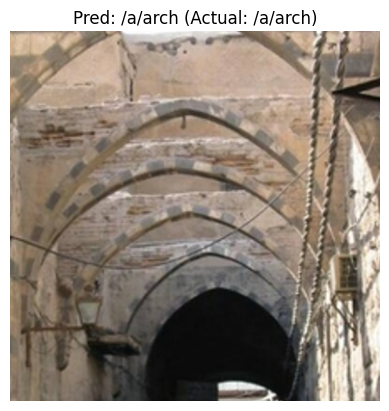

In [ ]:
# A.4 Prediction Evidence
model_a4.eval()
x, y = valset_a4[0]  # Get any validation example
with torch.no_grad():
    with autocast():
        pred = model_a4(x.unsqueeze(0).to(device_a4)).softmax(1)

# valset_a4 already has transform applied, so x is a tensor — convert back to image for display
from torchvision.transforms.functional import to_pil_image
mu_t = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
sig_t = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
img_display = to_pil_image((x.cpu() * sig_t + mu_t).clamp(0, 1))

plt.imshow(img_display)
plt.title(f"Pred: {trainset_a4.categories[pred.argmax().item()]} (Actual: {trainset_a4.categories[y]})")
plt.axis("off")
plt.show()